## EJERCICIO PRACTICO CLASE 3

GRUPO 4 - INTEGRANTES
- DARIO WLADIMIR HERRERA CHÁVEZ
- SANTIAGO PAUL GUALLICHICO ATI
- ROBINSON  DAMIAN CHILUISA GALLARDO

## Modelos de clasificación evaluados

Se evaluaron los siguientes algoritmos de clasificación supervisada:

- LR: Regresión Logística
- K-NN: K-Nearest Neighbors
- NB: Naive Bayes
- DT: Árbol de Decisión
- RF: Random Forest
- ANN: Red Neuronal Artificial (MLP)
- SVM: Support Vector Machine


2. Imports y carga del dataset

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import joblib
import os
import matplotlib.pyplot as plt

In [6]:
# Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

models = {
    "LR": LogisticRegression(max_iter=1000),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf")
}

In [8]:
results_no_pca = {}

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))

    joblib.dump(pipe, f"{name}_nopca.pkl")
    size_kb = os.path.getsize(f"{name}_nopca.pkl") / 1024

    results_no_pca[name] = {
        "accuracy": acc,
        "size": size_kb
    }

In [9]:
results_pca = {}

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=6)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))

    joblib.dump(pipe, f"{name}_pca.pkl")
    size_kb = os.path.getsize(f"{name}_pca.pkl") / 1024

    results_pca[name] = {
        "accuracy": acc,
        "size": size_kb
    }

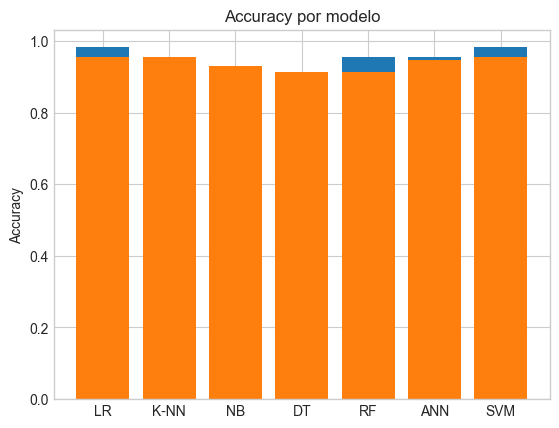

In [10]:
models_names = list(models.keys())
acc_no_pca = [results_no_pca[m]["accuracy"] for m in models_names]
acc_pca = [results_pca[m]["accuracy"] for m in models_names]

plt.figure()
plt.bar(models_names, acc_no_pca)
plt.bar(models_names, acc_pca, bottom=0)
plt.title("Accuracy por modelo")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

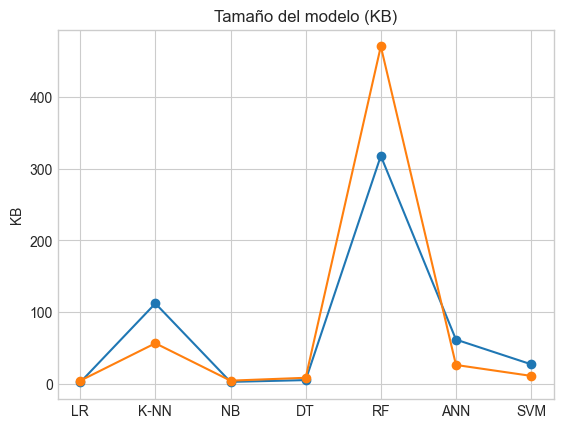

In [11]:
size_no_pca = [results_no_pca[m]["size"] for m in models_names]
size_pca = [results_pca[m]["size"] for m in models_names]

plt.figure()
plt.plot(models_names, size_no_pca, marker='o')
plt.plot(models_names, size_pca, marker='o')
plt.title("Tamaño del modelo (KB)")
plt.ylabel("KB")
plt.grid(True)
plt.show()

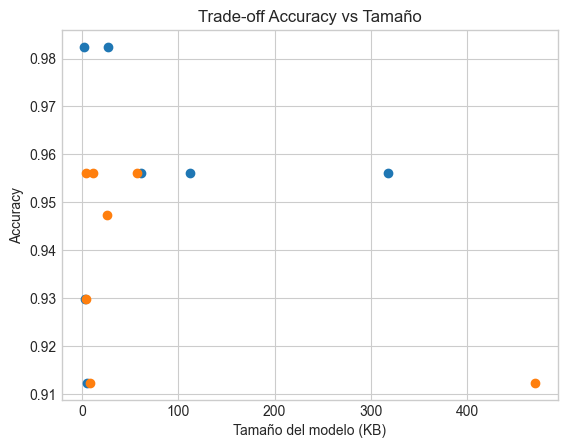

In [12]:
plt.figure()
plt.scatter(size_no_pca, acc_no_pca)
plt.scatter(size_pca, acc_pca)
plt.xlabel("Tamaño del modelo (KB)")
plt.ylabel("Accuracy")
plt.title("Trade-off Accuracy vs Tamaño")
plt.grid(True)
plt.show()

In [13]:
import pandas as pd

rows = []

for m in models_names:
    rows.append({
        "Modelo": m,
        "Accuracy": results_no_pca[m]["accuracy"],
        "KB (sin PCA)": results_no_pca[m]["size"],
        "KB (PCA 6)": results_pca[m]["size"]
    })

df_results = pd.DataFrame(rows)
df_results.to_csv("resultados_modelos.csv", index=False)

print(df_results)

  Modelo  Accuracy  KB (sin PCA)  KB (PCA 6)
0     LR  0.982456      2.188477    4.438477
1   K-NN  0.956140    112.169922   56.671875
2     NB  0.929825      2.829102    4.532227
3     DT  0.912281      5.315430    8.534180
4     RF  0.956140    317.861328  470.611328
5    ANN  0.956140     61.797852   26.422852
6    SVM  0.982456     27.356445   11.184570


C:\Users\ROBIN\AppData\Local\Temp\ipykernel_21196\3749884111.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_no_pca, acc_pca], labels=["Sin PCA", "Con PCA"])


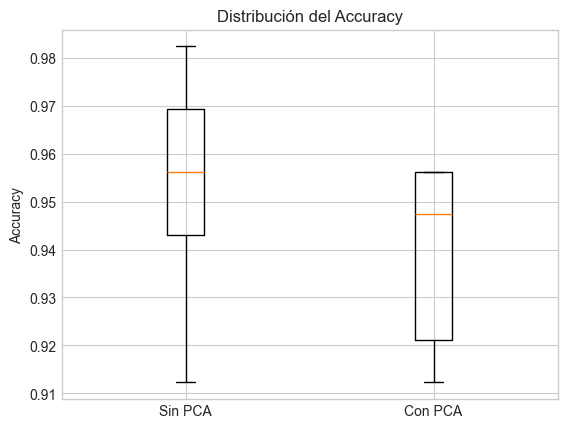

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([acc_no_pca, acc_pca], labels=["Sin PCA", "Con PCA"])
plt.ylabel("Accuracy")
plt.title("Distribución del Accuracy")
plt.grid(True)
plt.show()

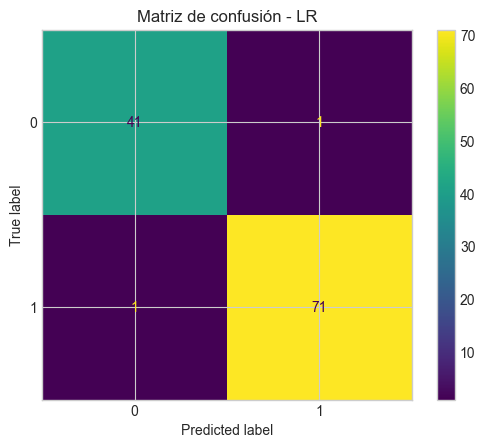

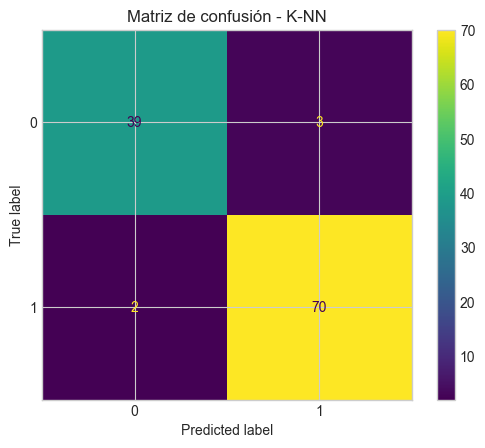

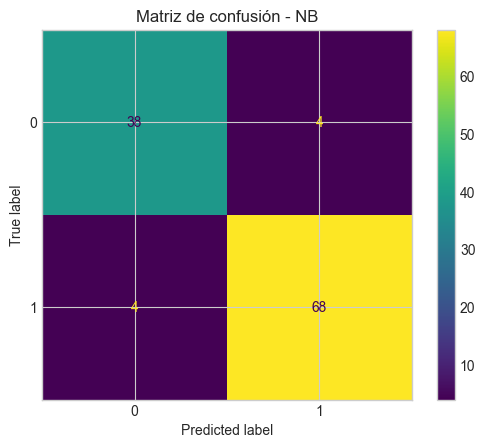

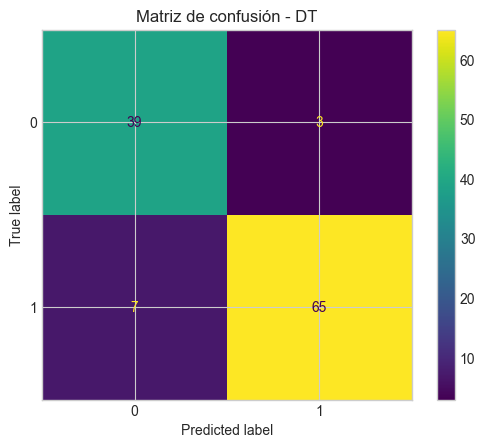

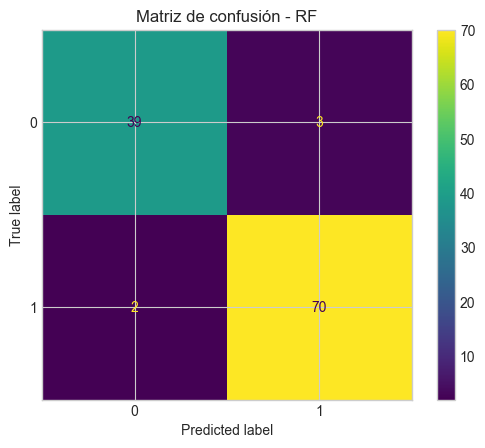

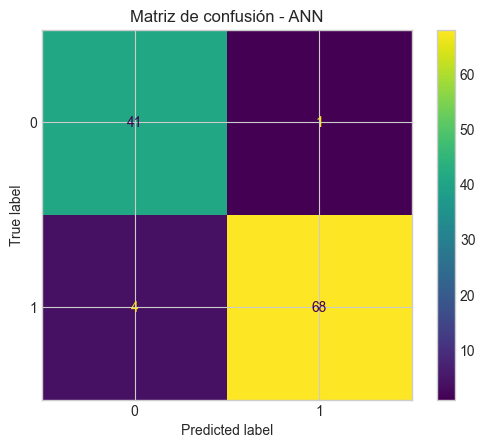

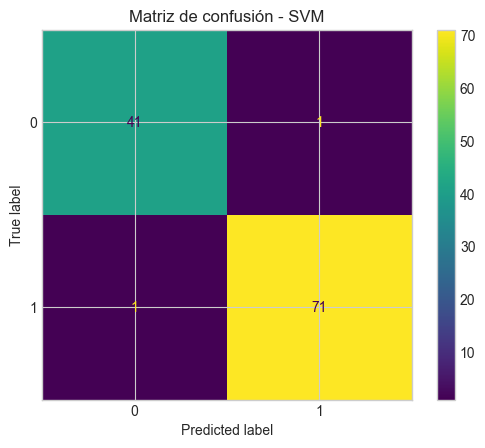

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)

    disp.plot()
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

## Conclusiones generales

Se evaluaron distintos modelos de clasificación supervisada para la predicción
del cáncer de mama, analizando tanto el rendimiento predictivo como el tamaño
del modelo.

Los resultados muestran que:
- PCA reduce significativamente el tamaño del modelo.
- La mayoría de los clasificadores mantienen un Accuracy elevado.
- K-NN y SVM se benefician notablemente de la reducción de dimensionalidad.
- Los modelos basados en árboles son menos sensibles a PCA.
- GridSearch permite optimizar el rendimiento sin aumentar la complejidad.

Este análisis demuestra la importancia de evaluar múltiples métricas
en problemas reales de Machine Learning.

## 2. Modelos Evaluados

Las siglas corresponden a los siguientes modelos:

| Sigla | Modelo |
|------|-------|
| LR | Logistic Regression |
| K-NN | K-Nearest Neighbors |
| NB | Naive Bayes |
| DT | Decision Tree |
| RF | Random Forest |
| ANN | Artificial Neural Network (MLP) |
| SVM | Support Vector Machine |

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [17]:
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

6. Escalado de Datos

El escalado se ajusta solo con el conjunto de entrenamiento para evitar fuga de información.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

Varianza explicada total: 0.633581100677249


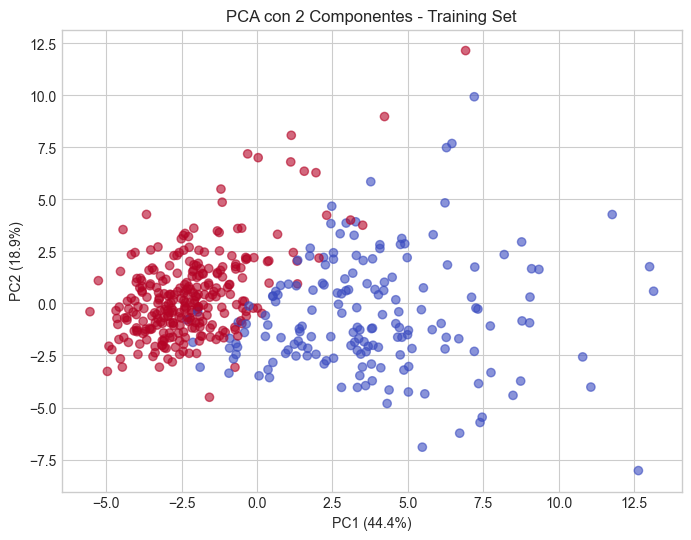

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA con 2 Componentes - Training Set")
plt.grid(True)
plt.show()

In [22]:
models = {
    "LR": LogisticRegression(max_iter=1000),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf")
}

In [23]:
acc_no_pca = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc_no_pca[name] = accuracy_score(y_test, y_pred)

In [24]:
acc_pca_2 = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    acc_pca_2[name] = accuracy_score(y_test, y_pred)

In [25]:
print("Modelo | Acc sin PCA | Acc con PCA (2)")
print("-"*35)

for model in models.keys():
    print(f"{model:5} | {acc_no_pca[model]:.3f} | {acc_pca_2[model]:.3f}")

Modelo | Acc sin PCA | Acc con PCA (2)
-----------------------------------
LR    | 0.982 | 0.947
K-NN  | 0.956 | 0.921
NB    | 0.930 | 0.912
DT    | 0.912 | 0.939
RF    | 0.956 | 0.921
ANN   | 0.956 | 0.939
SVM   | 0.982 | 0.947


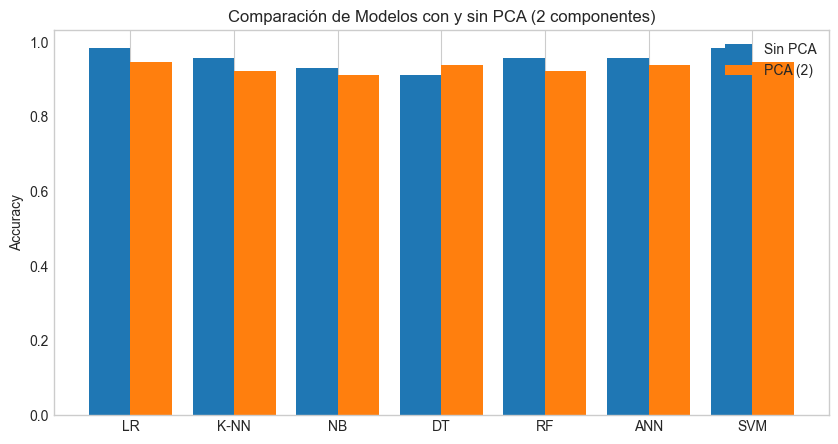

In [26]:
labels = list(models.keys())
x = np.arange(len(labels))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, acc_no_pca.values(), width=0.4, label="Sin PCA")
plt.bar(x + 0.2, acc_pca_2.values(), width=0.4, label="PCA (2)")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos con y sin PCA (2 componentes)")
plt.legend()
plt.grid(axis="y")
plt.show()

In [27]:
import pandas as pd

tabla_resultados = pd.DataFrame({
    "Modelo": list(models.keys()),
    "Accuracy sin PCA": list(acc_no_pca.values()),
    "Accuracy PCA (2)": list(acc_pca_2.values())
})

tabla_resultados

,Modelo,Accuracy sin PCA,Accuracy PCA (2)
0,LR,0.982456,0.947368
1,K-NN,0.956140,0.921053
2,NB,0.929825,0.912281
3,DT,0.912281,0.938596
4,RF,0.956140,0.921053
5,ANN,0.956140,0.938596
6,SVM,0.982456,0.947368
